Training an Ensemble of 5 MLP Regressors...
Successfully trained all 5 models in the ensemble.


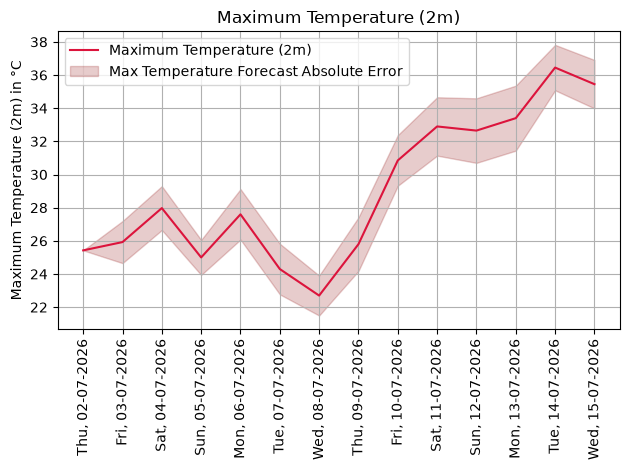

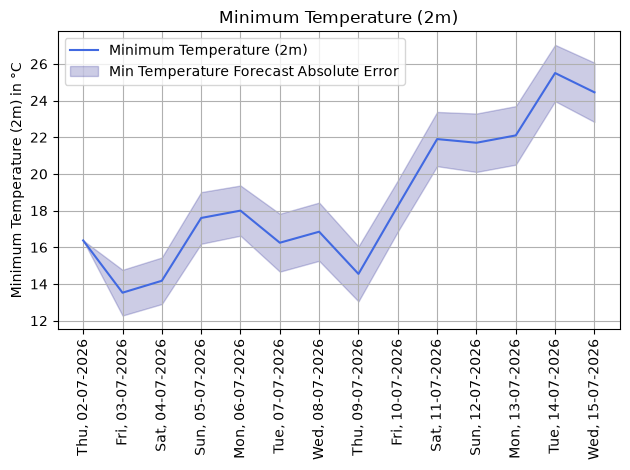

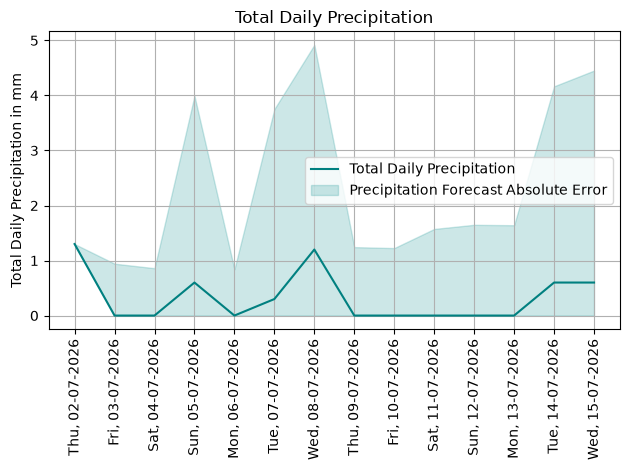

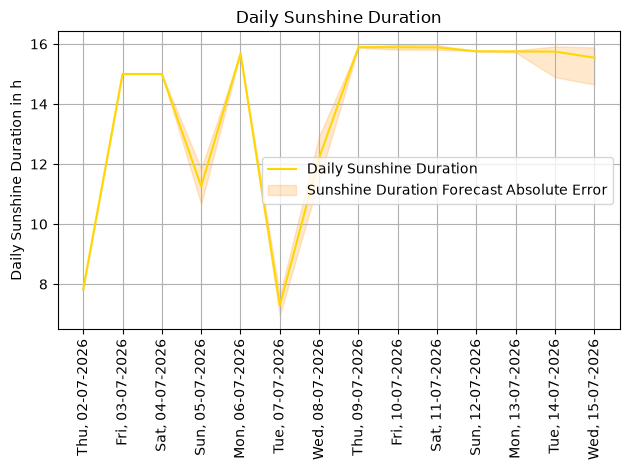

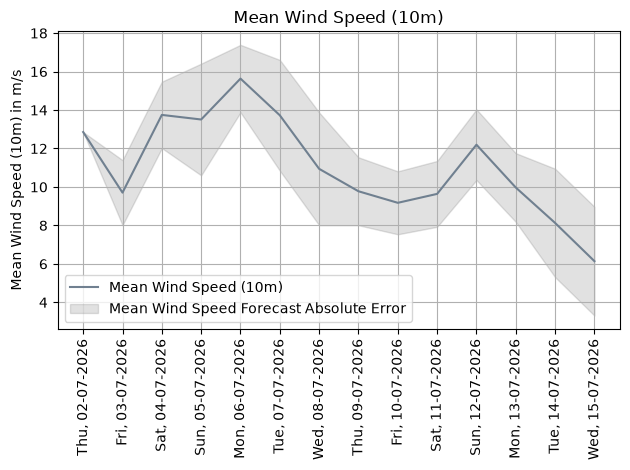

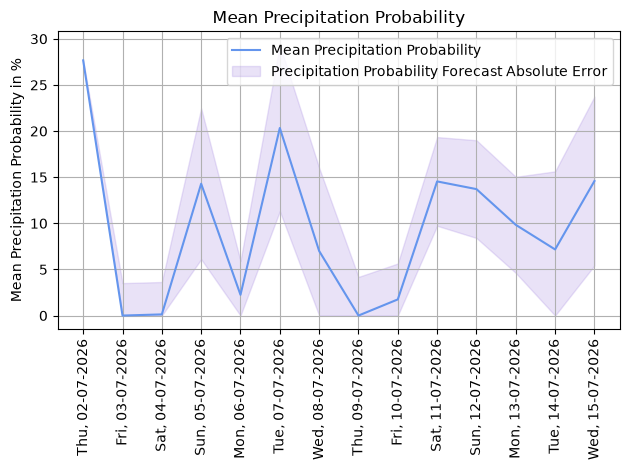

In [1]:
import pandas as pd

from fue import Config, Data, Forecast
from fue.models import MLUncertaintyModel

# ==========================================
# 1. Ingest and Pool Multi-City Datasets
# ==========================================
data = Data()
data.read_raw()

all_city_records = []

config = Config()
for city in config.city_coordinates.keys():
    # Use val_fraction=0.0 here so we gather 100% of the city data into a list first
    city_df, _ = data.generate_dataset(location_name=city, val_fraction=0.0)
    all_city_records.append(city_df)

# Combine datasets vertically into one unified DataFrame (~1000+ total rows)
combined_dataset = pd.concat(all_city_records, ignore_index=True)

# Shuffle the combined rows deterministically and apply an 80/20 train/validation split
shuffled_dataset = combined_dataset.sample(frac=1.0, random_state=42).reset_index(drop=True)
split_idx = int(len(shuffled_dataset) * 0.8)

train_df = shuffled_dataset.iloc[:split_idx].reset_index(drop=True)
val_df = shuffled_dataset.iloc[split_idx:].reset_index(drop=True)

# ==========================================
# 2. Instantiate Model and Configure Columns
# ==========================================

# Explicitly ensure location markers are part of features so the network adjusts to microclimates
feature_columns = ["latitude", "longitude"] + config.default_feature_columns
target_columns = config.default_target_columns  # .remove("abs_diff__sunshine_duration")

# We use slightly stronger regularization (alpha=0.01) to protect the network weights
model = MLUncertaintyModel(hidden_layer_sizes=(16, 8), alpha=0.01)
model.fit(combined_dataset, feature_columns, target_columns)
F = Forecast()
F.fetch_forecast(location_name="aachen", forecast_days=14, past_days=0)
F.compute_uncertainties(model)
F.plot(target_variables=target_columns)

Training an Ensemble of 5 MLP Regressors...


/home/linden/code/uni/sce/fue/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/linden/code/uni/sce/fue/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Successfully trained all 5 models in the ensemble.
Training an Ensemble of 5 MLP Regressors...
Successfully trained all 5 models in the ensemble.
Training an Ensemble of 5 MLP Regressors...


/home/linden/code/uni/sce/fue/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/linden/code/uni/sce/fue/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Successfully trained all 5 models in the ensemble.
Training an Ensemble of 5 MLP Regressors...


/home/linden/code/uni/sce/fue/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Successfully trained all 5 models in the ensemble.
Training an Ensemble of 5 MLP Regressors...
Successfully trained all 5 models in the ensemble.
Training an Ensemble of 5 MLP Regressors...
Successfully trained all 5 models in the ensemble.
Training an Ensemble of 5 MLP Regressors...
Successfully trained all 5 models in the ensemble.
Training an Ensemble of 5 MLP Regressors...
Successfully trained all 5 models in the ensemble.
Training an Ensemble of 5 MLP Regressors...
Successfully trained all 5 models in the ensemble.
Training an Ensemble of 5 MLP Regressors...
Successfully trained all 5 models in the ensemble.


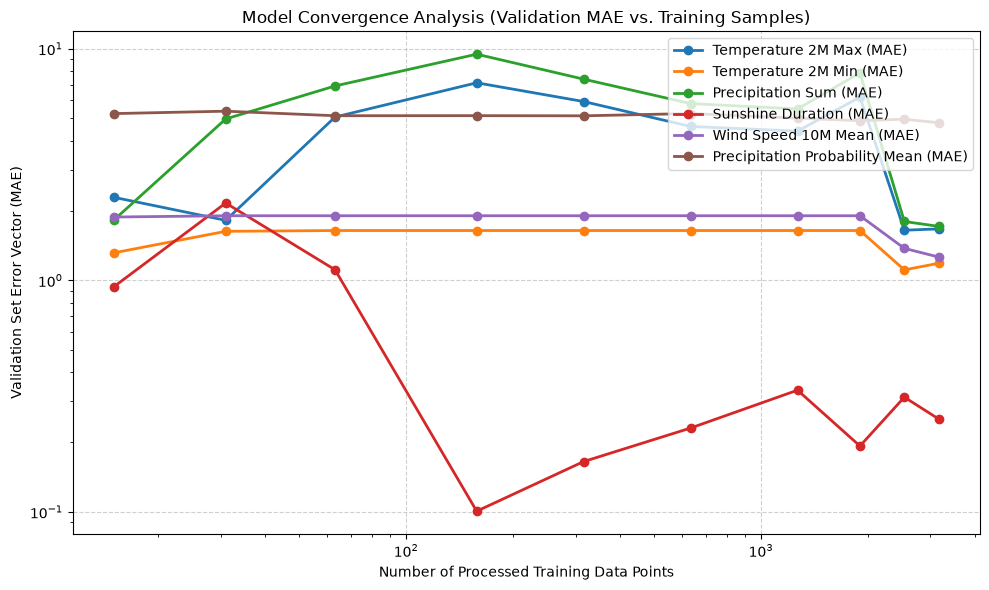

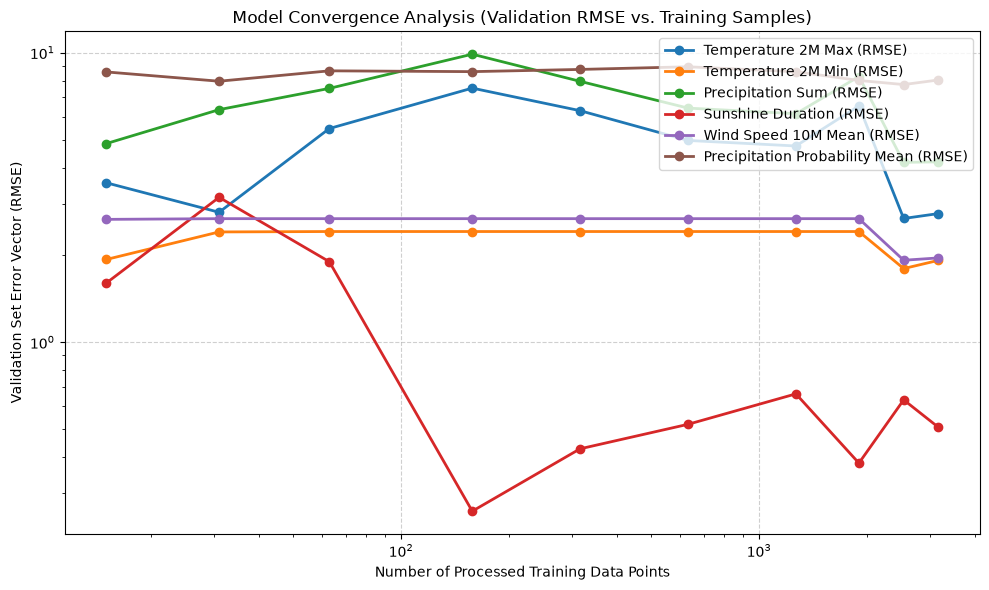

Training an Ensemble of 5 MLP Regressors...
Successfully trained all 5 models in the ensemble.

Final Multi-City Validation Set Error Metrics:
  abs_diff__temperature_2m_max: MAE=1.6672, RMSE=2.7786
  abs_diff__temperature_2m_min: MAE=1.1847, RMSE=1.9151
  abs_diff__precipitation_sum: MAE=1.7096, RMSE=4.1918
  abs_diff__sunshine_duration: MAE=0.2517, RMSE=0.5079
  abs_diff__wind_speed_10m_mean: MAE=1.2598, RMSE=1.9529
  abs_diff__precipitation_probability_mean: MAE=4.7890, RMSE=8.0398


In [2]:
# ==========================================
# 3. Run and Visually Plot Convergence Study
# ==========================================
# Compute errors across increasing data slices
convergence_results = model.study_data_convergence(train_df, val_df, feature_columns, target_columns)

# Trigger the newly implemented plotting capability
model.plot_learning_curve(convergence_results, metric="MAE")
model.plot_learning_curve(convergence_results, metric="RMSE")


# ==========================================
# 4. Final Evaluation Summary
# ==========================================
# Train the model statefully on the full 80% data pool
model.fit(train_df, feature_columns, target_columns)

# Get the final error metrics on the remaining 20% validation data
final_metrics = model.evaluate(val_df)

print("\nFinal Multi-City Validation Set Error Metrics:")
for target, metrics in final_metrics.items():
    print(f"  {target}: MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}")

In [3]:
data2 = Data()
data2.read_raw()
dataset, _ = data2.generate_dataset(location_name="aachen", val_fraction=0)
print(len(dataset))

396
